In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost 
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
)
from imblearn.under_sampling import TomekLinks
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [50]:

df = pd.read_csv('Copia de data_merged.csv')



In [51]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000

def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (no popular): 39729 (23.1%)
   1 (Baja): 34033 (19.8%)
   2 (Media): 51035 (29.6%)
   3 (Alta): 47433 (27.5%)


<Axes: xlabel='popularity_multiclass'>

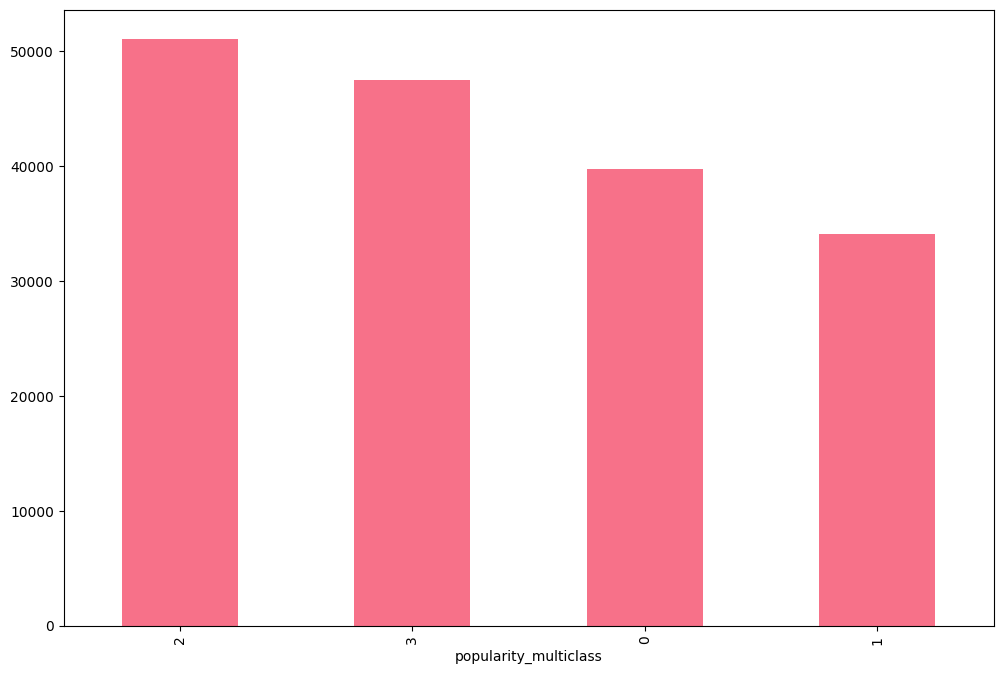

In [52]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [53]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [54]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,39729.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,34033.0,9.619575,6.125172,1.0,4.0,9.0,15.0,20.0
2,51035.0,30.747330,5.652618,21.0,26.0,31.0,36.0,40.0
3,47433.0,54.153163,9.966513,41.0,46.0,52.0,61.0,100.0


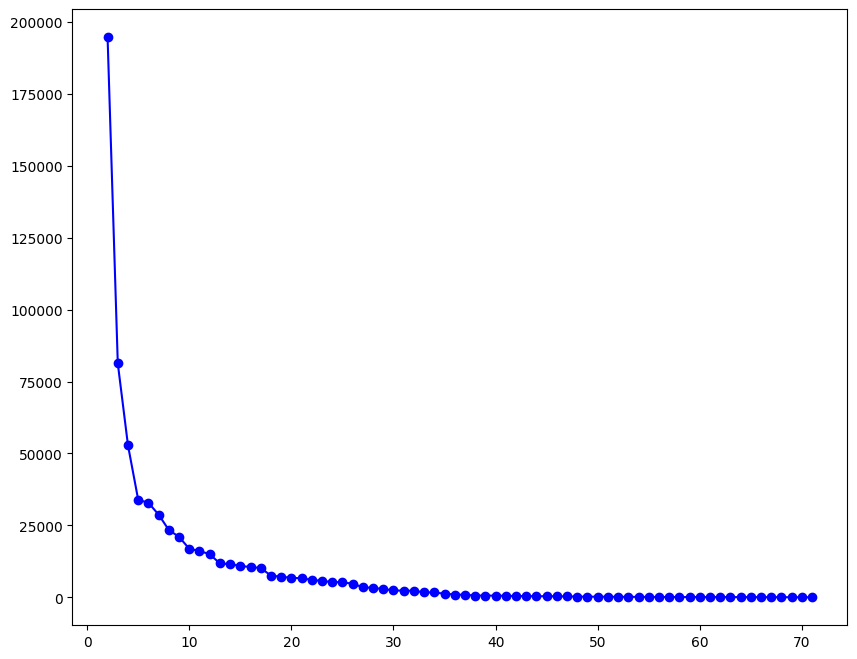

In [55]:

selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [56]:
selector = SelectKBest(score_func=f_classif,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['popularity_ar', 'acousticness_yr', 'energy_yr',
       'instrumentalness_yr', 'tempo_yr', 'popularity_yr'], dtype=object)

In [57]:
_X=X[select]
y =y_multiclass_3

In [58]:
scaler1 = StandardScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)


In [59]:
rus = TomekLinks()
newX, newy = rus.fit_resample(X_train_reduce,y_train_reduce)
X_train_reduce = scaler1.fit_transform(newX)
X_test_scaled = scaler1.transform(X_test_reduce)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time=  28.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=  28.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=  28.5s
[CV] END ...................max_depth=None, n_estimators=100; total time=  28.5s
[CV] END ...................max_depth=None, n_estimators=100; total time=  28.8s
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END .....................max_depth=10, n_estimators=100; total time=  19.1s
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END .....................max_depth=10, n_est

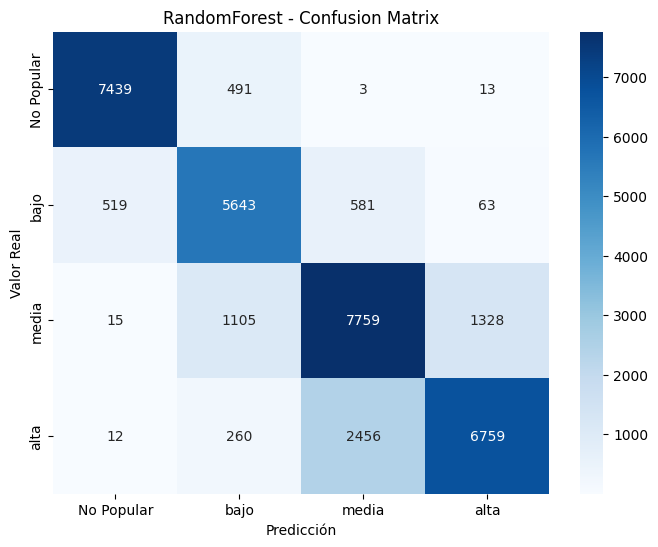

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..........................max_depth=3, max_iter=100; total time=   6.9s
[CV] END ..........................max_depth=3, max_iter=100; total time=   7.0s
[CV] END ..........................max_depth=3, max_iter=100; total time=   7.0s
[CV] END ..........................max_depth=3, max_iter=100; total time=   7.0s
[CV] END ..........................max_depth=3, max_iter=100; total time=   7.0s
[CV] END ..........................max_depth=3, max_iter=200; total time=  13.4s
[CV] END ..........................max_depth=3, max_iter=200; total time=  13.4s
[CV] END ..........................max_depth=3, max_iter=200; total time=  13.4s
[CV] END ..........................max_depth=3, max_iter=200; total time=  13.4s
[CV] END ..........................max_depth=3, max_iter=200; total time=  13.5s
[CV] END ..........................max_depth=5, max_iter=100; total time=   9.5s
[CV] END ..........................max_depth=3, m

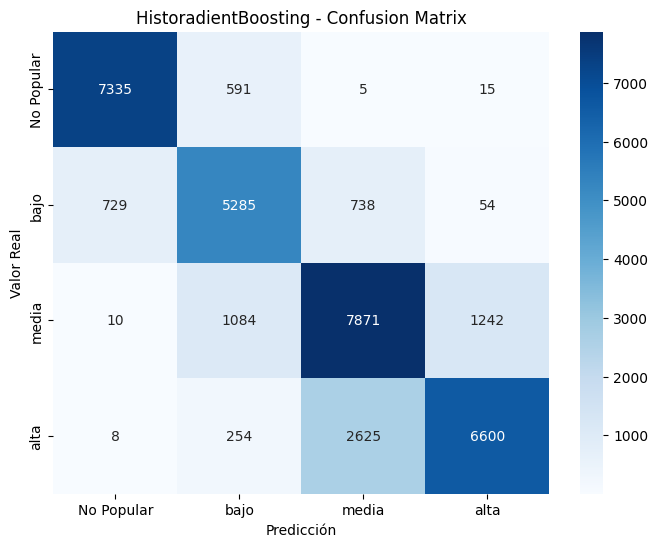

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ......................max_depth=3, n_estimators=100; total time=   6.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   6.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   6.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   6.6s
[CV] END ......................max_depth=3, n_estimators=100; total time=   6.6s
[CV] END ......................max_depth=3, n_estimators=300; total time=  19.1s
[CV] END ......................max_depth=3, n_estimators=300; total time=  19.1s
[CV] END ......................max_depth=3, n_estimators=300; total time=  19.2s
[CV] END ......................max_depth=3, n_estimators=300; total time=  19.2s
[CV] END ......................max_depth=3, n_estimators=300; total time=  19.3s
[CV] END .....................max_depth=10, n_estimators=100; total time=  13.4s
[CV] END ......................max_depth=3, n_est

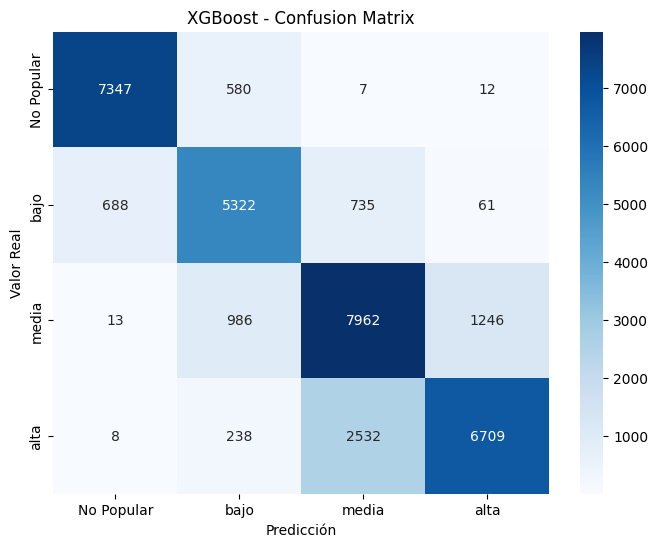

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.1s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.3s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=  27.5s
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END .....................max_depth=10, n_estimators=100; total time=  15.5s
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=300; total time= 1.4min
[CV] END .....................max_depth=10, n_est

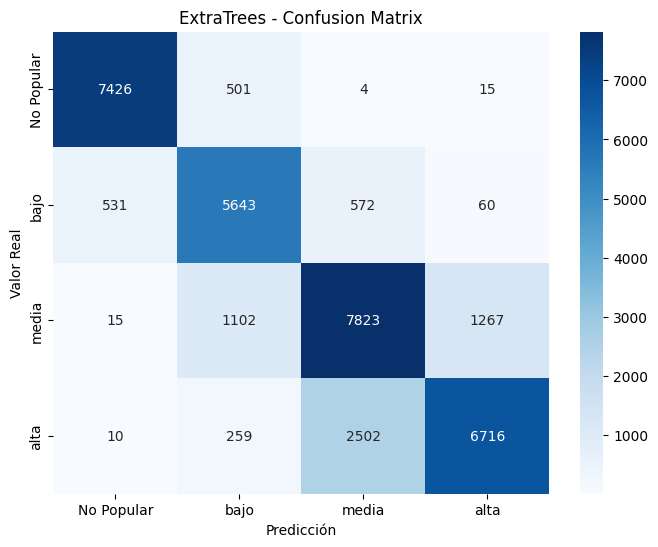

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .......................................max_depth=10; total time=   0.8s
[CV] END .......................................max_depth=10; total time=   0.8s
[CV] END .......................................max_depth=10; total time=   0.8s
[CV] END .....................................max_depth=None; total time=   1.0s
[CV] END .....................................max_depth=None; total time=   1.1s
[CV] END .....................................max_depth=None; total time=   1.1s
[CV] END .....................................max_depth=None; total time=   1.1s
[CV] END .....................................max_depth=None; total time=   1.0s
[CV] END .......................................max_depth=10; total time=   0.7s
[CV] END .......................................max_depth=10; total time=   0.7s
[CV] END .......................................max_depth=20; total time=   0.8s
[CV] END .......................................m

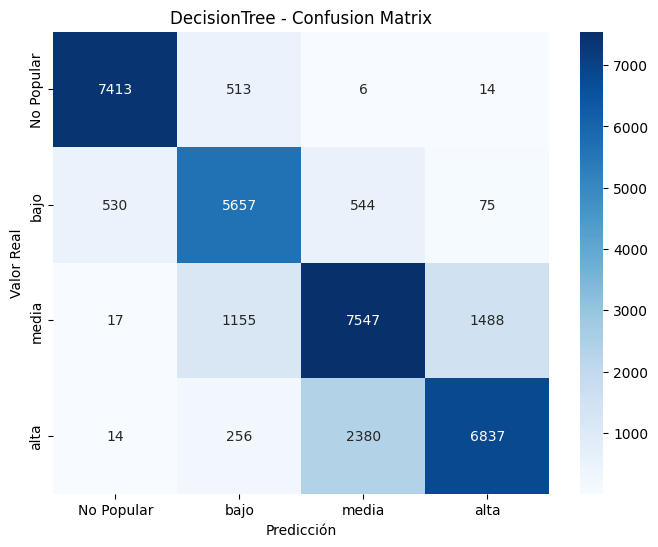

In [60]:
from sklearn.ensemble import ExtraTreesClassifier,HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],

    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, newy)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

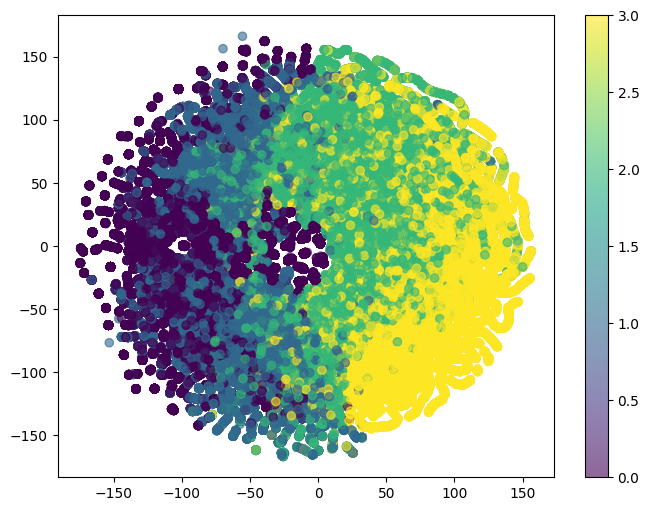

In [61]:

tsne = TSNE(n_components=2,random_state=42)
X_tsne  = tsne.fit_transform(newX)
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=newy,cmap='viridis',alpha=0.6)
plt.colorbar()
plt.show()